# INF8111 - Fouille de données
## Été 2026 - TP1 - Préparation des données de séries temporelles-Consommation électrique
### Membres de l'équipe
<span style="color:blue">**FAYE, Ousmane - 2490131** </span><br>
<span style="color:blue">**BOUSLAH, Soumeya - 2511549**</span><br>
<span style="color:blue">**DUVAL, Thomas - 2152675** </span>


## Instructions de remise

Vous devez remettre dans la boîte de remise sur moodle ce fichier nommé TP1\_NomDuMembre1\_NomDuMembre2\_NomDuMembre3.ipynb

**N.B**: Assurez-vous que tous les résultats soient lisibles lorsque le notebook est ouvert.

Ce notebook doit être remis avant le **24 mai 2026 à 23h59***. À l'ouverture du Notebook, toutes les réponses doivent être visibles. Tout travail en retard sera pénalisé d’une valeur de 10\% par jour ouvrable de retard.

## Barème

    Partie 1: 20 points
    
    Partie 2: 30 points
    
    Partie 3: 50 points
    
    Pour un total de 100 points.

## Séries temporelles

Les séries temporelles sont de plus en plus utilisées dans plusieurs domaines tels aue la finance, la météorologie, la santé et la gestion de l'énergie pour modéliser, analyser et prévoir des phénomènes évolutifs. Une série temporelle correspond à une suite d’observations ordonnées dans le temps, collectées à intervalles réguliers ou irréguliers (par exemple : prix journaliers d’une action, température horaire, consommation électrique, etc.).
Ces données présentent une structure particulière caractérisée par la dépendance entre les observations successives. À partir de ces données temporelles, il devient possible d’identifier des tendances à long terme, des cycles saisonniers, ainsi que des anomalies ou événements inhabituels. Par exemple, en finance, elles servent à anticiper les fluctuations des marchés ; en météorologie, à prévoir les conditions climatiques ; en santé, à suivre l’évolution de paramètres physiologiques ; et dans l’énergie, à optimiser la production ou la consommation.

    
### But
Le but de ce TP est de vous donner un aperçu de la fouille de données dans le cas des séries temporelles. En raison des crises énergétiques, des études de fouille et d'analyse de données peuvent être faites afin de prendre des décisions qui favorisent une consommation optimale de l'énergie électrique. Le but de ce TP est d'extraire des informations pertinentes à partir des données de consommation d'énergie électrique qui sont fournies.

### Importation des différents modules

In [2]:
# Installation des librairies

!pip3 install pandas
!pip3 install numpy
!pip3 install scikit-learn
!pip3 install seaborn
!pip3 install matplotlib
!pip3 install plotly
!pip3 install statsmodels

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Informations sur les données
Nous vous avons fourni le fichier data.csv avec l'exécution de cellule suivante. Il contient l'ensemble des données. Il s'agit des mesures collectées dans une maison située à Sceaux (à 7 km de Paris, France) entre décembre 2006 et novembre 2010. Chaque ligne contient les données d'une vente. La description des attributs du dataset est la suivante:

| # | Feature Name           | Description |
|---|------------------------|-------------|
| 1 | Date                  | Date / Date au format jj/mm/aaaa |
| 2 | Time                  | Heure / Heure au format hh:mm:ss |
| 3 | Global_active_power   | Puissance active globale / Household global minute-averaged active power (in kilowatt) |
| 4 | Global_reactive_power | Puissance réactive globale / Household global minute-averaged reactive power (in kilowatt) |
| 5 | Voltage               | Tension / Minute-averaged voltage (in volt) |
| 6 | Global_intensity      | Intensité globale / Household global minute-averaged current intensity (in ampere) |
| 7 | Sub_metering_1        | Sous-comptage 1 / Energy sub-metering No. 1 (cuisine : lave-vaisselle, four, micro-ondes) |
| 8 | Sub_metering_2        | Sous-comptage 2 / Energy sub-metering No. 2 (buanderie : machine à laver, sèche-linge, réfrigérateur, lumière) |
| 9 | Sub_metering_3        | Sous-comptage 3 / Energy sub-metering No. 3 (chauffage électrique et climatisation) |

Notons que (global_active_power×1000/60−sub_metering_1−sub_metering_2−sub_metering_3) représente l’énergie active consommée chaque minute (en watt-heure) dans le foyer par les équipements électriques non mesurés par les sous-compteurs 1, 2 et 3.

In [4]:
df = pd.read_csv("data.txt", sep=";", na_values=["?"],low_memory=False)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data.txt'

# 1. Nettoyage et préparation de données (5 points)

#### Question 1.1 ( 2 points)
**Combien d'observations contient le dataset ?

In [29]:
# TO DO
nbr_bef = df.index.size
print(nbr_bef)

2075259


#### Question 1.2 (3 points)

Supprimer les lignes ayant des valeurs manquantes puis indiquer le nombre de lignes supprimées.  

In [41]:
# TO DO
df = df.dropna()
nbr_af = len(df)
nbr_rem = nbr_bef - nbr_af

print(f"Nomre de lignes avant suppression des valeurs manquantes : {nbr_bef}")
print(f"Nomre de lignes après  suppression des valeurs manquantes  : {nbr_af}")
print(f"Nomre de lignes supprimées : {nbr_rem}")

Nomre de lignes avant suppression des valeurs manquantes : 2075259
Nomre de lignes après  suppression des valeurs manquantes  : 2049280
Nomre de lignes supprimées : 25979


####  Question 1.3 (4 points)
En visualisant les colonnes du dataset, et en se référant à la description fournie, quels sont les attributs numériques?

In [42]:
df.select_dtypes(include=['number']).columns

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')

#### Question 1.4 (5 points)

On veut combiner les colonnes **Date** et **Time** pour créer une seule variable temporelle **dt**, représentant l’instant exact de chaque observation. La colonne **dt** doit être au format **aaaa-mm-jj hh:mm:ss**. Transformez les colonnes **Date** et **Time** en **dt**.

In [48]:
df = pd.read_csv("data.txt", sep=";", na_values=["?"], low_memory=False)
df = df.dropna()
# Création la colonne dt
df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# Supprimons Date et Time et mettons dt en premier
df = df.drop(columns=['Date', 'Time'])
cols = ['dt'] + [c for c in df.columns if c != 'dt']
df = df[cols]

# Vérification
print(f"Type de dt : {df['dt'].dtype}")
print(df.head())


Type de dt : datetime64[us]
                   dt  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  


#### Question 1.5 (7,5 points)
a - Afficher la matrice de corrélation entre les différents attributs numériques de nos données. Quelle sont les paires d'attributs fortement correlés ? Utiliser un seuil de 0,75.

Matrice de corrélation :
                       Global_active_power  Global_reactive_power  Voltage  \
Global_active_power                 1.0000                 0.2470  -0.3998   
Global_reactive_power               0.2470                 1.0000  -0.1122   
Voltage                            -0.3998                -0.1122   1.0000   
Global_intensity                    0.9989                 0.2661  -0.4114   
Sub_metering_1                      0.4844                 0.1231  -0.1960   
Sub_metering_2                      0.4346                 0.1392  -0.1674   
Sub_metering_3                      0.6386                 0.0896  -0.2682   

                       Global_intensity  Sub_metering_1  Sub_metering_2  \
Global_active_power              0.9989          0.4844          0.4346   
Global_reactive_power            0.2661          0.1231          0.1392   
Voltage                         -0.4114         -0.1960         -0.1674   
Global_intensity                 1.0000          0

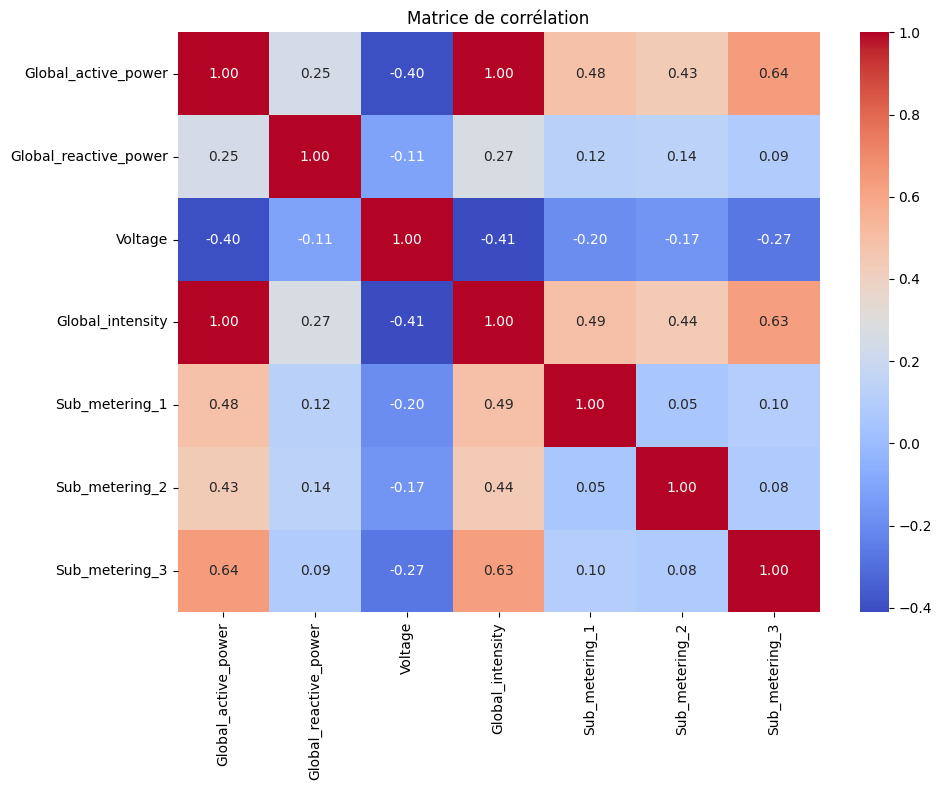


Paires d'attributs fortement corrélés (seuil >= 0.75) :
  - Global_active_power et Global_intensity : 0.9989

Paire la plus fortement corrélée : Global_active_power et Global_intensity avec une corrélation de 0.9989


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des colonnes numériques
numerical_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

# Calcul de la matrice de corrélation
correlation_matrix = df[numerical_cols].corr()

# Affichage des valeurs de la matrice de corrélation
print("Matrice de corrélation :")
print(correlation_matrix.round(4))

# Affichage sous forme de heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

# Identification des paires fortement corrélées (seuil >= 0.75)
print("\nPaires d'attributs fortement corrélés (seuil >= 0.75) :")
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        val = correlation_matrix.loc[col1, col2]
        if abs(val) >= 0.75:
            print(f"  - {col1} et {col2} : {val:.4f}")

# Affichage la paire la plus fortement corrélée
max_corr = 0
pair_max = ("", "")
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        val = abs(correlation_matrix.loc[col1, col2])
        if val > max_corr:
            max_corr = val
            pair_max = (col1, col2)

print(f"\nPaire la plus fortement corrélée : {pair_max[0]} et {pair_max[1]} avec une corrélation de {max_corr:.4f}")


b- Afficher sur un graphe la relation entre les deux attributs ayant la plus forte corrélation.

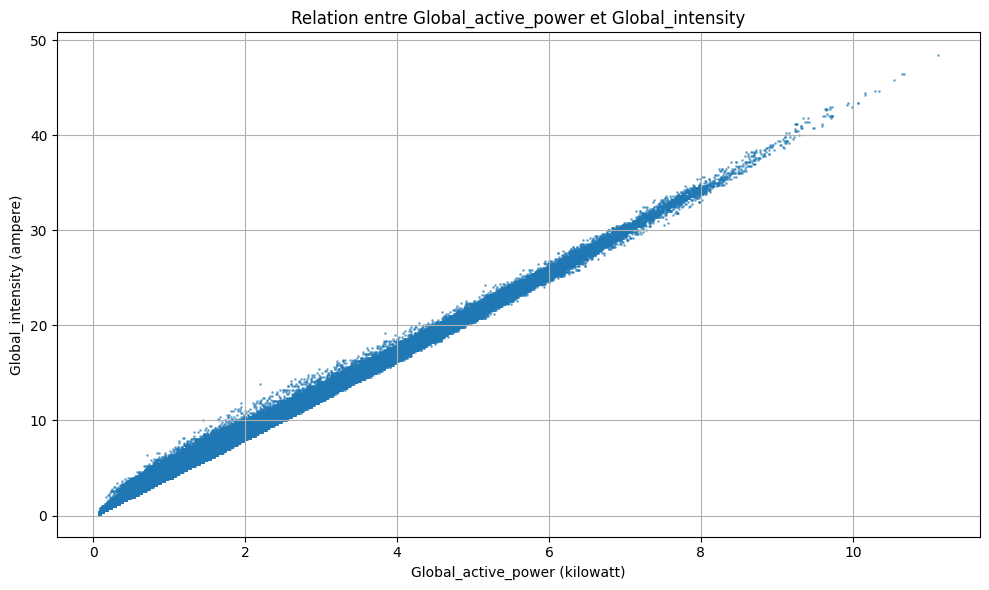

In [92]:
# TO DO
plt.figure(figsize=(10, 6))
plt.scatter(df['Global_active_power'], df['Global_intensity'], alpha=0.5, s=1)
plt.title('Relation entre Global_active_power et Global_intensity')
plt.xlabel('Global_active_power (kilowatt)')
plt.ylabel('Global_intensity (ampere)')
plt.grid(True)
plt.tight_layout()
plt.show()



- <span style="color:green">Ceci s'explique physiquement car la puissance active est directement proportionnelle à l'intensité du courant (𝑃=𝑉×𝐼).</span>

# 2. Prédiction standard
De façon classique, un modèle de prédiction indique une relation entre des variables d'entrée et une variable à prédire. Dans cette partie, nous allons prédire  **Global_active_power** en utilisant les autres colonnes.

#### Question 2.1   (5 points)
Pour l'ensemble des données, créer un ensemble de données nommé **data** en remplaçant la colonne **dt** par de nouvelles colonnes **annee**, **mois**, **jour**, **heure** et **minutes**.
Indiquer pourquoi la colonne **secondes** peut être ignorée pour notre ensemble de données.

In [93]:
dt_col = df['dt']

# Créons data sans dt
data = df.drop(columns=['dt']).copy()

# Ajoutons les nouvelles colonnes temporelles
data.insert(0, 'annee', dt_col.dt.year)
data.insert(1, 'mois', dt_col.dt.month)
data.insert(2, 'jour', dt_col.dt.day)
data.insert(3, 'heure', dt_col.dt.hour)
data.insert(4, 'minutes', dt_col.dt.minute)

# Affichage
print(data.head())
print(f"\nDimensions du dataset : {data.shape}")


   annee  mois  jour  heure  minutes  Global_active_power  \
0   2006    12    16     17       24                4.216   
1   2006    12    16     17       25                5.360   
2   2006    12    16     17       26                5.374   
3   2006    12    16     17       27                5.388   
4   2006    12    16     17       28                3.666   

   Global_reactive_power  Voltage  Global_intensity  Sub_metering_1  \
0                  0.418   234.84              18.4             0.0   
1                  0.436   233.63              23.0             0.0   
2                  0.498   233.29              23.0             0.0   
3                  0.502   233.74              23.0             0.0   
4                  0.528   235.68              15.8             0.0   

   Sub_metering_2  Sub_metering_3  
0             1.0            17.0  
1             1.0            16.0  
2             2.0            17.0  
3             1.0            17.0  
4             1.0         

- <span style="color:green"> La colonne 'secondes' peut être ignorée car toutes les observations ont été collectées à intervalles d'une minute exacte. La valeur des secondes est donc toujours égale à 0 pour l'ensemble des données, ce qui en fait une variable constante qui n'apporte aucune information supplémentaire au modèle.</span>

#### Question 2.2 (5 points)
On peut normaliser les données.

*   La `standardisation` normalise les données en soustrayant la moyenne et en divisant par l'écart-type
*   `Min-Max Scaling` normalise les données en les ramenant entre 0 et 1.

Réaliser la normalisation des données par `standardisation`. On peut utiliser la fonction `StandardScaler()` de `sklearn`.

In [94]:
# TO DO
from sklearn.preprocessing import StandardScaler

# Normalisation par standardisation

# Séparons la variable cible des features
X = data.drop(columns=['Global_active_power'])
y = data['Global_active_power']

# Appliquons la standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reconvertissons le en DataFrame pour garder les noms de colonnes
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Vérification
print("Avant standardisation :")
print(data.drop(columns=['Global_active_power']).describe().round(2))

print("\nAprès standardisation :")
print(X_scaled.describe().round(2))


Avant standardisation :
            annee        mois        jour       heure     minutes  \
count  2049280.00  2049280.00  2049280.00  2049280.00  2049280.00   
mean      2008.42        6.45       15.71       11.50       29.50   
std          1.12        3.42        8.80        6.93       17.32   
min       2006.00        1.00        1.00        0.00        0.00   
25%       2007.00        3.00        8.00        5.00       15.00   
50%       2008.00        6.00       16.00       12.00       30.00   
75%       2009.00        9.00       23.00       18.00       45.00   
max       2010.00       12.00       31.00       23.00       59.00   

       Global_reactive_power     Voltage  Global_intensity  Sub_metering_1  \
count             2049280.00  2049280.00        2049280.00      2049280.00   
mean                    0.12      240.84              4.63            1.12   
std                     0.11        3.24              4.44            6.15   
min                     0.00      223.20  

#### Question 2.3 (5 points)
On va séparer les données en un ensemble d'entraînement et un ensemble de test qu'on va nommer respectivement 'data_train' et 'data_test'. Utiliser les données jusqu'à fin 2009 pour l'apprentissage, et celles de 2010 pour le test.

Effectuer la séparartion des données.

In [96]:
# TO DO

# Données l'entraînement
data_train = data[data['annee'] <= 2009]

# Données test
data_test = data[data['annee'] == 2010]

# Séparons les features et la variable cible
X_train = data_train.drop(columns=['Global_active_power'])
y_train = data_train['Global_active_power']

X_test = data_test.drop(columns=['Global_active_power'])
y_test = data_test['Global_active_power']

# Appliquons la standardisation sur train et test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

# Vérification
print(f"Taille de l'ensemble d'entraînement : {X_train.shape}")
print(f"Taille de l'ensemble de test : {X_test.shape}")
print(f"\nPériode d'entraînement : {data_train['annee'].min()} - {data_train['annee'].max()}")
print(f"Période de test : {data_test['annee'].min()} - {data_test['annee'].max()}")


Taille de l'ensemble d'entraînement : (1591886, 11)
Taille de l'ensemble de test : (457394, 11)

Période d'entraînement : 2006 - 2009
Période de test : 2010 - 2010


### Question 2.4 - Entrainement de modèle de régression linéaire

La régression linéaire consiste à trouver une fonction affine qui minimise la somme des carrés des erreurs. La fonction affine est définie par la formule suivante :
$$ f(x) = \beta_0 + \beta_1^T x $$
Il consiste à trouver les paramètres $\beta_0$ et $\beta_1$ qui minimisent $\sum_{i=1}^n (f(x_i) - y_i)^2=||y-X\beta||^2$ où $X$ est la matrice des données fournies au modèle et $y$ le vecteur des `Global_active_power`.

La métrique RMSE (Root Mean Square Error) est une métrique utilisée pour mesurer la différence moyenne entre les valeurs prédites par un modèle et les valeurs observées.

#### Question 2.4.1 (10 points )
Entrainer un modèle de regresion linéaire avec **data_train** et  calculer la RMSE correspondante aux données de l'ensemble de test.

In [55]:
# TO DO
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Entraînement du modèle
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Prédiction sur les données de test
y_pred = lr_model.predict(X_test_scaled)

# Calcul de la RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE sur les données de test : {rmse:.4f}")


RMSE sur les données de test : 0.0394


La prédiction est obtenue. On peut maintenant mesurer l'importance de chaque attribut dans la prédicition en se référant aux coefficients de la régression linéaire.
#### Question 2.4.2  (5 points)
Quels sont les trois attributs ayant le plus d'impact dans la prédiction ?

Importance des attributs (par ordre décroissant) :
                 Attribut  Coefficient
7        Global_intensity     1.089580
5   Global_reactive_power     0.019616
10         Sub_metering_3     0.018422
6                 Voltage     0.014649
3                   heure     0.003081
9          Sub_metering_2     0.002727
1                    mois     0.000733
8          Sub_metering_1     0.000584
2                    jour     0.000455
0                   annee     0.000215
4                 minutes     0.000097

Les 3 attributs ayant le plus d'impact :
                 Attribut  Coefficient
7        Global_intensity     1.089580
5   Global_reactive_power     0.019616
10         Sub_metering_3     0.018422


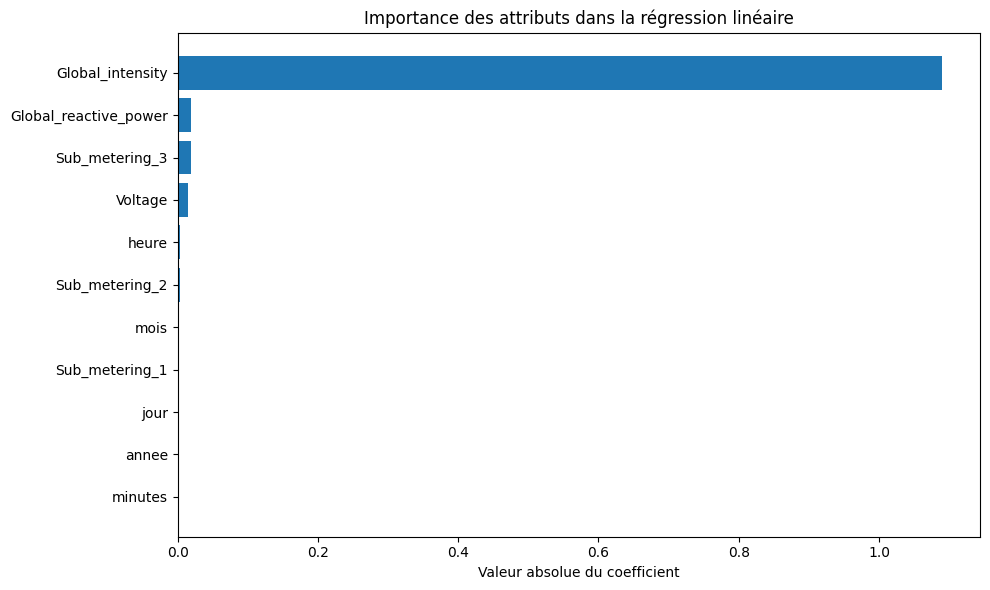

In [58]:
# TO DO
# Récupérons les coefficients du modèle
coefficients = pd.DataFrame({
    'Attribut': X_train.columns,
    'Coefficient': np.abs(lr_model.coef_)  # valeur absolue pour mesurer l'impact
}).sort_values(by='Coefficient', ascending=False)

print("Importance des attributs (par ordre décroissant) :")
print(coefficients)

# Affichons les 3 attributs les plus importants
print("\nLes 3 attributs ayant le plus d'impact :")
print(coefficients.head(3))

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Attribut'], coefficients['Coefficient'])
plt.xlabel('Valeur absolue du coefficient')
plt.title("Importance des attributs dans la régression linéaire")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [69]:
# On copie les données pour les utiliser dans la partie 3.
dft = df.copy()

# 3. Prédiction de série temporelle
Dans la partie précédente, la prédiction d'une valeur nécessite la connaissance des valeurs des autres attributs de l'observation concernée. On n'a pas toujours ces valeurs et pourtant on peut faire de prédiction dans ces situations. Les séries temporelles sont plus adaptées dans ces situations. La prédiction de séries temporelles consiste à estimer les valeurs futures d’une variable en se basant sur ses observations passées.

Dans la suite du TP, seuls les attributs **Global_active_power** et **dt** vont être utilisés. La cellule suivante permet de réduire les données.

In [70]:
# Réduisons les données à Global_active_power avec dt comme index
dft = dft.set_index('dt')
dft = dft['Global_active_power']
dft

dt
2006-12-16 17:24:00    4.216
2006-12-16 17:25:00    5.360
2006-12-16 17:26:00    5.374
2006-12-16 17:27:00    5.388
2006-12-16 17:28:00    3.666
                       ...  
2010-11-26 20:58:00    0.946
2010-11-26 20:59:00    0.944
2010-11-26 21:00:00    0.938
2010-11-26 21:01:00    0.934
2010-11-26 21:02:00    0.932
Name: Global_active_power, Length: 2049280, dtype: float64

## 3.1 Analyse préliminaire des données

#### Question 3.1.1 ( 3 points)
Calculer et afficher sur un graphe la consommation moyenne de **Global_active_power** pour chaque mois de l'année.

Consommation moyenne par mois :
Jan    1.4622
Fév    1.3004
Mar    1.2313
Avr    1.0471
Mai    1.0296
Jun    0.9091
Jul    0.7004
Aoû    0.5728
Sep    0.9757
Oct    1.1371
Nov    1.2915
Déc    1.4897
Name: Global_active_power, dtype: float64


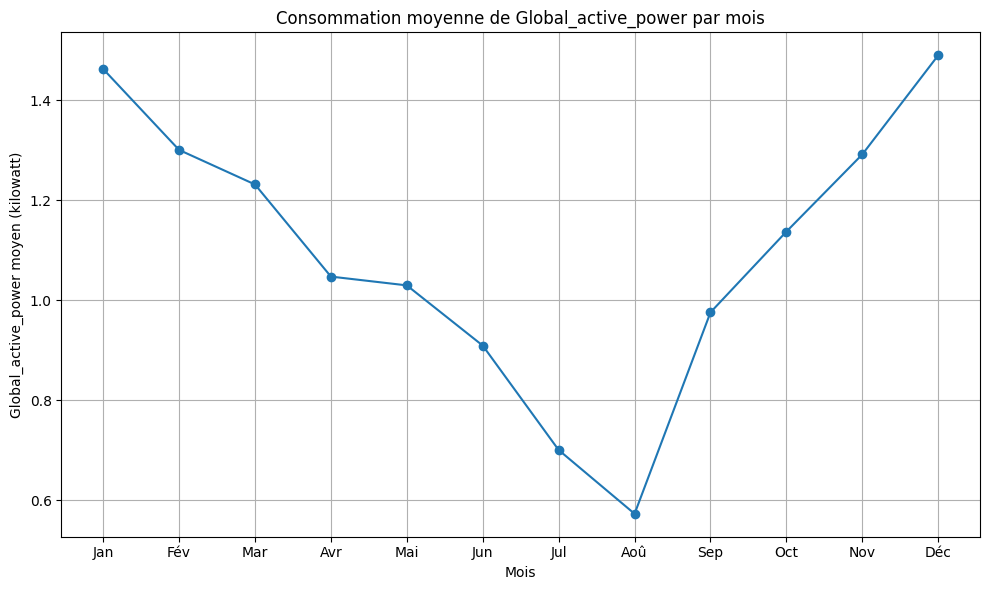

In [72]:
# TO DO
# Calculons la moyenne par mois
monthly_avg = dft.groupby(dft.index.month).mean()
monthly_avg.index = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 
                     'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

# Affichage
print("Consommation moyenne par mois :")
print(monthly_avg.round(4))

# Graphique
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title('Consommation moyenne de Global_active_power par mois')
plt.xlabel('Mois')
plt.ylabel('Global_active_power moyen (kilowatt)')
plt.grid(True)
plt.tight_layout()
plt.show()


Les données fournies sont en minutes. Pour la suite du TP, on va réduire la taille des données en faisant un rééchantillonnage des données en utilisant la somme par jour. La cellule suivante permet de faire cette réduction et de visualiser les données obtenues.

<Axes: xlabel='dt'>

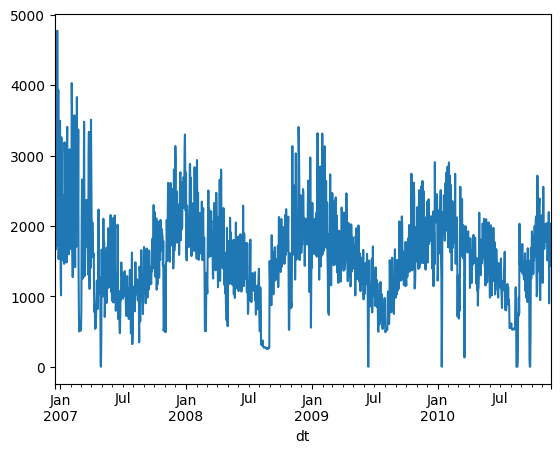

In [75]:
# Exécuter ce code pour afficher les données réduites
df_journalier = dft.resample('D').sum()
df_journalier.plot()

#### Question 3.1.2 (3 points)
En utilisant la fonction **seasonal_decompose** de la librairie **statsmodels**, effectuer une décomposition de la série temporelle journalière (df_journalier) avec une période de 6 mois.

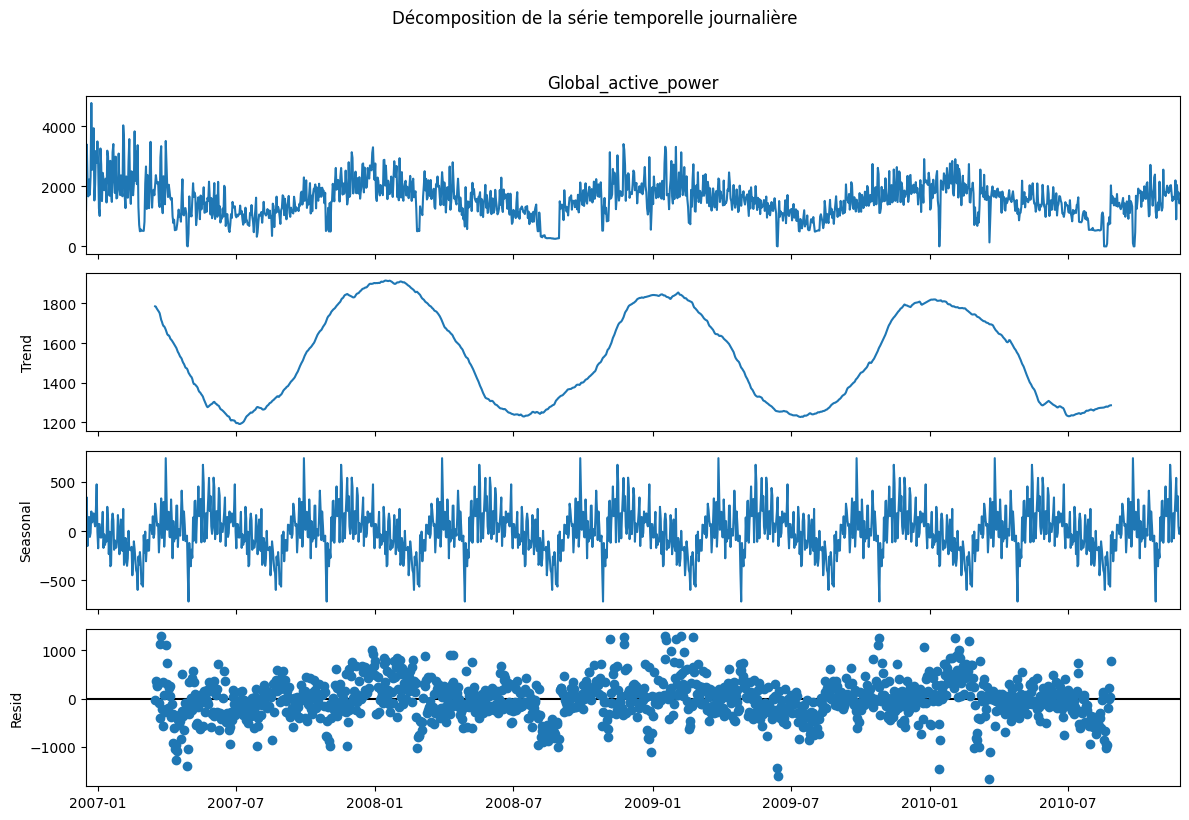

In [76]:
# TO DO
from statsmodels.tsa.seasonal import seasonal_decompose

# Rééchantillonnage par jour (somme)
df_journalier = dft.resample('D').sum()

# Décomposition avec une période de 6 mois (environ 182 jours)
decomposition = seasonal_decompose(df_journalier, model='additive', period=182)

# Affichage
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Décomposition de la série temporelle journalière', y=1.02)
plt.tight_layout()
plt.show()


#### Question 3.1.3 (4 points)
Interpréter les résultats obtenus aux questions 3.1.1 et 3.1.2.
    Quelle périodicité observe-t-on ?
    Quels mois présentent une consommation plus élevée ?
    Cette information est-elle cohérente avec un usage domestique ?

##### TO DO
- <span style="color:green"> Périodicité observée
On observe une périodicité **annuelle** dans la consommation électrique. 
La série temporelle se répète de façon similaire chaque année, 
ce qui est confirmé par la composante saisonnière de la décomposition.</span>

- <span style="color:green"> Mois avec consommation plus élevée
Les mois présentant une consommation plus élevée sont les mois 
**d'hiver (Décembre, Janvier, Février)** et dans une moindre mesure 
les mois **d'automne (Octobre, Novembre)**. 
À l'inverse, les mois **d'été (Juin, Juillet, Août)** présentent 
une consommation plus faible.</span>

- <span style="color:green"> Cohérence avec un usage domestique
Oui, cette information est **cohérente avec un usage domestique** car :


 <span style="color:green">En hiver, la consommation augmente en raison du **chauffage électrique**
  et de l'**éclairage** (les jours sont plus courts).</span>

  
 <span style="color:green">En été, la consommation diminue car les besoins en chauffage 
  sont réduits et les journées sont plus longues.</span>
  
 <span style="color:green">Cela est d'autant plus cohérent que les données proviennent 
  d'une maison située à **Sceaux, France**, où les hivers 
  sont froids et nécessitent un chauffage important.</span>



#### Question 3.1.4 (3 points)
Les **lag features** sont très utilisées dans la prédiction des séries temporelles. Elles permettent de saisir les tendances temporelles des données en générant de nouvelles variables à partir des valeurs passées. Ces variables permettent d'utiliser les valeurs passées pour prédire les valeurs futures. Par exemple, la prédiction de la consommation d'aujourd'hui pourrait dépendre de la consommation du même jour de l'année passée. Dans ce cas, la consommation d'il y a un an constituerait une lag feature.
Vous pouvez consulter le [lien](https://www.kaggle.com/code/ryanholbrook/time-series-as-features/tutorial) suivant pour un apperçu du lag embedding.


Quelle valeur est adéqate pour une variable lagged dans ce cas ? Justifier votre réponse.

###### TO DO (aucun code n'est requis pour répondre à cette question)

##### Valeur choisie : lag = 365 jours

<span style="color:green"> Justification
Une valeur de **365 jours** (1 an) est adéquate pour une variable 
laggée dans ce cas car :</span>

- <span style="color:green">On a observé dans les questions 3.1.1 et 3.1.2 une **périodicité 
  annuelle** dans la consommation électrique.</span>
- <span style="color:green"> La consommation d'un jour donné est fortement influencée par 
  la consommation du **même jour de l'année précédente**, car les 
  habitudes de consommation se répètent d'une année à l'autre 
  (chauffage en hiver, moins de consommation en été).</span>
- <span style="color:green"> Utiliser un lag de 365 jours permet donc de capturer cette 
  **saisonnalité annuelle** et d'améliorer la précision des prédictions.</span>


### 3.2  Modèle de régression linéaire
Nous allons appliquer la régression linéaire sur nos données réduites. Pour cela, on doit transformer le problème de séries temporelles en un problème d'apprentissage supervisé. On va créer des "lagged features" pour accomplir cette tâche, puis diviser les données obtenues en des ensembles d'apprentissage et de test, respectivement les données jusqu'à fin 2009 pour l'apprentissage, et celles de 2010 pour le test.

#### Question 3.2 (12.5 points)
Entraîner un modèle de regresion linéaire dans ce cas. Pour cela, créer une variable 'lags' permettant de garder en mémoire à chaque jour la consommation d'un jour du passé. Calculer la RMSE correspondante aux données prédites.

In [97]:
# TO DO
# Créons la variable laggée (lag = 365 jours)
df_lag = pd.DataFrame()
df_lag['Global_active_power'] = df_journalier
df_lag['lag_365'] = df_journalier.shift(365)

# Supprimons les lignes avec des valeurs manquantes (dues au lag)
df_lag = df_lag.dropna()

# Séparons les données en train et test
train_lag = df_lag[df_lag.index.year <= 2009]
test_lag = df_lag[df_lag.index.year == 2010]

X_train_lag = train_lag[['lag_365']]
y_train_lag = train_lag['Global_active_power']

X_test_lag = test_lag[['lag_365']]
y_test_lag = test_lag['Global_active_power']

# Entraînement du modèle de régression linéaire
lr_ts = LinearRegression()
lr_ts.fit(X_train_lag, y_train_lag)

# Prédiction sur les données de test
y_pred_lag = lr_ts.predict(X_test_lag)

# Calcul de la RMSE
rmse_lr_ts = np.sqrt(mean_squared_error(y_test_lag, y_pred_lag))
print(f"RMSE Régression Linéaire (série temporelle) : {rmse_lr_ts:.4f}")


RMSE Régression Linéaire (série temporelle) : 500.8606


### 3.3 Entrainement d'un modèle au choix
#### Question 3.3 (12.5 points)
Pour les mêmes périodes de sous-ensembles de données, entrainer un modèle de votre choix et calculer la RMSE correspondante. Justifiez votre choix.

Toute tranformation des données réduites avant l'entrainement est autorisée ici. L'obtention d'un RMSE meilleur au précédent sera valorisée.

In [98]:
# TO DO
from sklearn.ensemble import RandomForestRegressor

# Créons plusieurs variables laggées pour enrichir le modèle
df_rf = pd.DataFrame()
df_rf['Global_active_power'] = df_journalier
df_rf['lag_365'] = df_journalier.shift(365)  # même jour l'année passée
df_rf['lag_7']   = df_journalier.shift(7)    # même jour la semaine passée
df_rf['lag_1']   = df_journalier.shift(1)    # jour précédent

# Supprimons les lignes avec des valeurs manquantes
df_rf = df_rf.dropna()

# Séparons les données en train et test
train_rf = df_rf[df_rf.index.year <= 2009]
test_rf  = df_rf[df_rf.index.year == 2010]

X_train_rf = train_rf[['lag_365', 'lag_7', 'lag_1']]
y_train_rf = train_rf['Global_active_power']

X_test_rf = test_rf[['lag_365', 'lag_7', 'lag_1']]
y_test_rf = test_rf['Global_active_power']

# Entraînement du modèle Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

# Prédiction sur les données de test
y_pred_rf = rf_model.predict(X_test_rf)

# Calcul de la RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
print(f"RMSE Régression Linéaire : {rmse_lr_ts:.4f}")
print(f"RMSE Random Forest       : {rmse_rf:.4f}")


RMSE Régression Linéaire : 500.8606
RMSE Random Forest       : 419.7422


#### Justification du choix : Random Forest

<span style="color:green"> Le modèle **Random Forest** a été choisi pour les raisons suivantes :</span>

- <span style="color:green">Il est capable de capturer des **relations non linéaires** entre 
  les variables, contrairement à la régression linéaire.</span>
- <span style="color:green">Il est **robuste aux valeurs aberrantes** et au bruit dans les données.</span>
- <span style="color:green">En utilisant plusieurs lag features (lag_1, lag_7, lag_365), 
  il peut capturer à la fois les tendances **journalières**, 
  **hebdomadaires** et **annuelles**.</span>
- <span style="color:green">Il est généralement plus performant que la régression linéaire 
  sur des données de séries temporelles complexes.</span>


### 3.4 Évaluation des deux modèles

#### Question 3.4.1 (7 points)
Pour chacun des deux modèles précédents, afficher sur une figure les observations réelles de **Global_active_power** et celles prédites en fonction du temps pour l'année 2010.

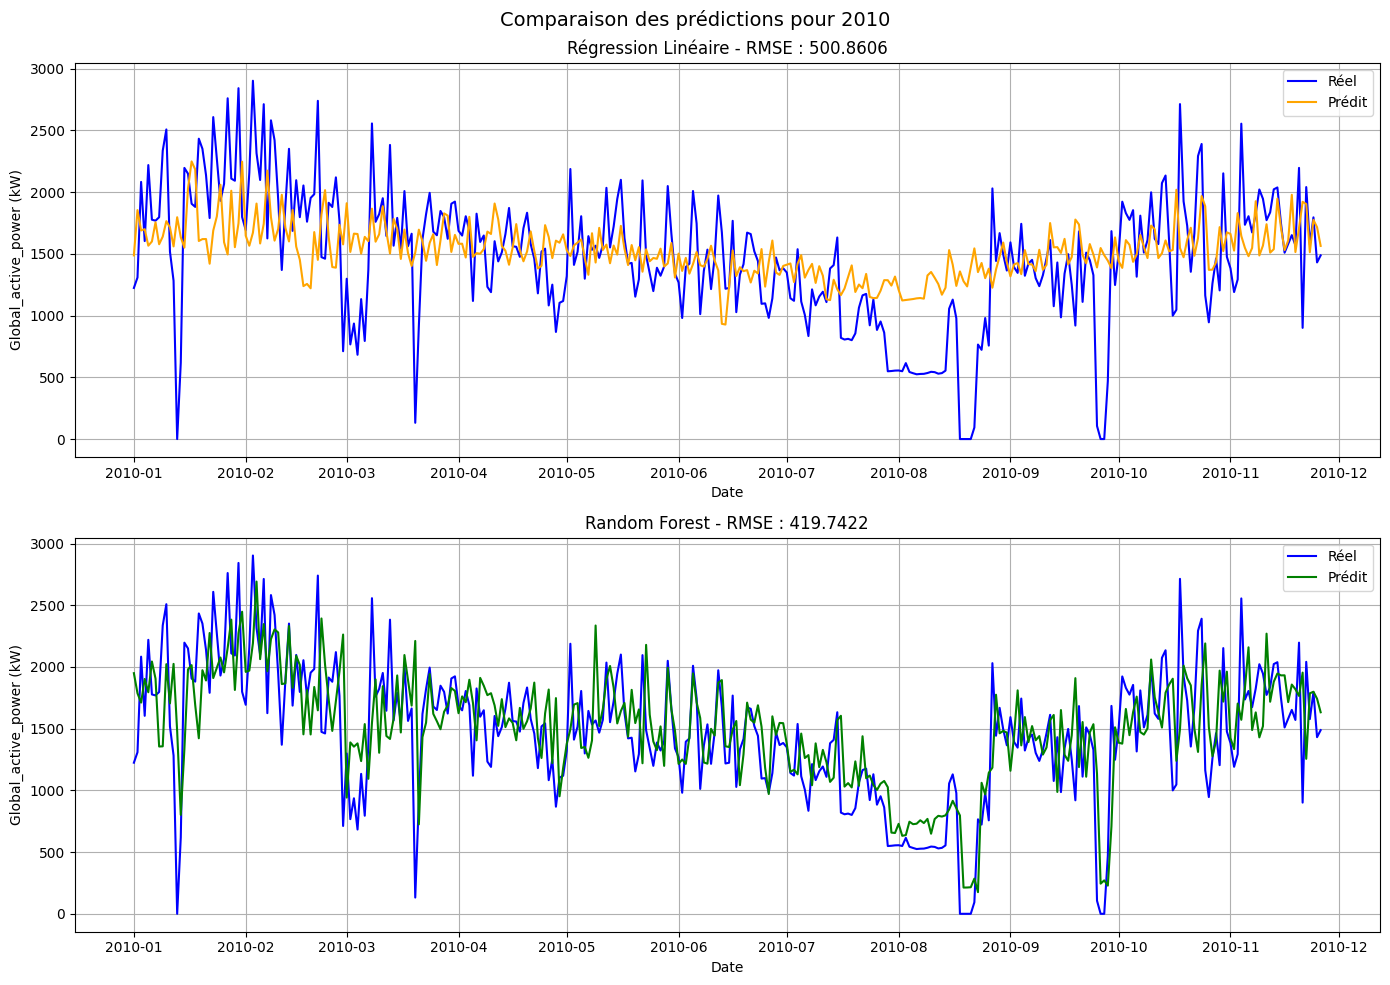

In [99]:
# TO DO
# Affichons les observations réelles et prédites pour 2010

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 - Régression Linéaire
axes[0].plot(test_lag.index, y_test_lag.values, label='Réel', color='blue')
axes[0].plot(test_lag.index, y_pred_lag, label='Prédit', color='orange')
axes[0].set_title(f'Régression Linéaire - RMSE : {rmse_lr_ts:.4f}')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Global_active_power (kW)')
axes[0].legend()
axes[0].grid(True)

# Graphique 2 - Random Forest
axes[1].plot(test_rf.index, y_test_rf.values, label='Réel', color='blue')
axes[1].plot(test_rf.index, y_pred_rf, label='Prédit', color='green')
axes[1].set_title(f'Random Forest - RMSE : {rmse_rf:.4f}')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Global_active_power (kW)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Comparaison des prédictions pour 2010', fontsize=14)
plt.tight_layout()
plt.show()



#### Question 3.4.2  (5 points)
En se basant sur les graphes obtenus à la question précédente et sur les RMSE obtenus pour les deux modèles, faites une analyse comparative des résultats.

### Analyse des graphiques
#### Régression Linéaire
- <span style="color:green">Le modèle de régression linéaire capture la **tendance générale** 
  de la consommation électrique mais avec moins de précision.</span>
- <span style="color:green">Les prédictions sont **moins fidèles** aux variations journalières 
  car le modèle ne peut capturer que des relations linéaires.</span>
- <span style="color:green">Avec un seul lag (365 jours), le modèle manque certaines 
  variations à court terme.</span>

#### Random Forest
- <span style="color:green">Le modèle Random Forest produit des prédictions **plus proches** 
  des valeurs réelles grâce à l'utilisation de plusieurs lag features
  (lag_1, lag_7, lag_365).</span>
- <span style="color:green">Il capture mieux les **variations à court terme** (journalières 
  et hebdomadaires) ainsi que les **tendances annuelles**.</span>
- <span style="color:green">La RMSE plus faible confirme que le Random Forest est 
  **plus performant** que la régression linéaire.</span>

#### Conclusion
<span style="color:green">Le modèle **Random Forest** est plus adapté pour la prédiction de 
cette série temporelle car :</span>
1. <span style="color:green">Il capture des relations **non linéaires** entre les variables.</span>
2. <span style="color:green">L'utilisation de **plusieurs lag features** lui permet de mieux 
   modéliser les différentes périodicités (journalière, hebdomadaire, annuelle).</span>
3. <span style="color:green">Sa **RMSE plus faible** confirme une meilleure capacité de généralisation 
   sur les données de test de 2010.</span>

